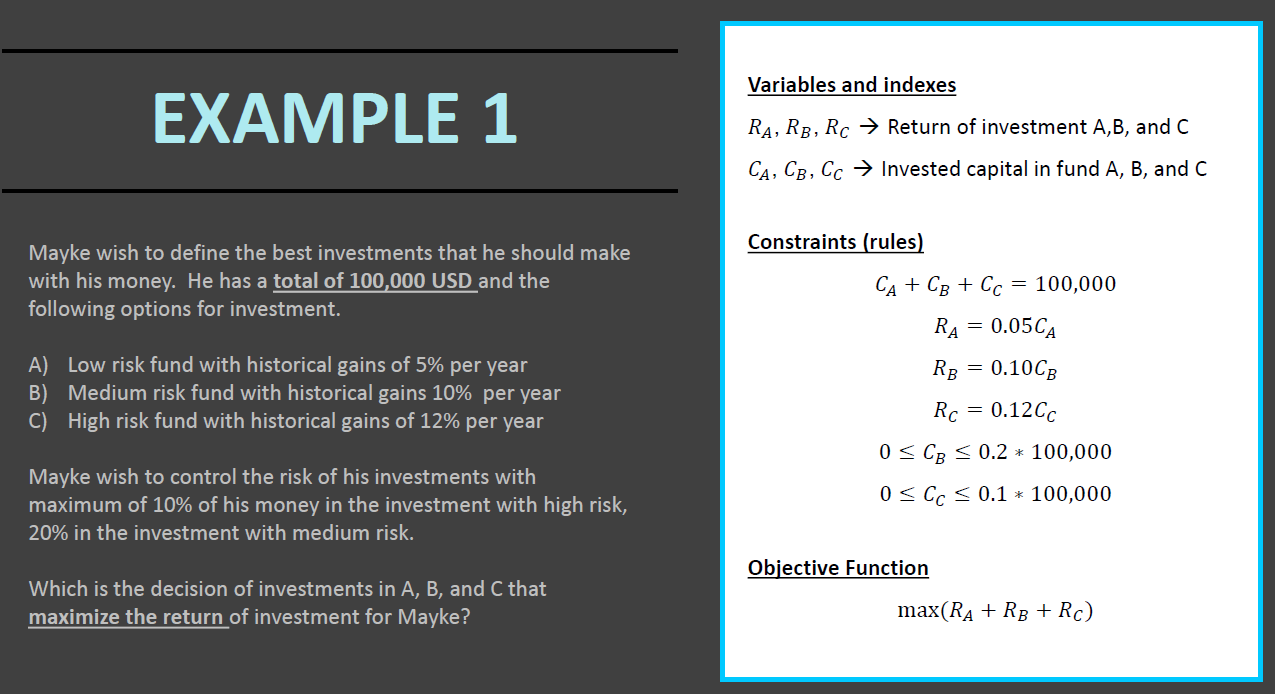
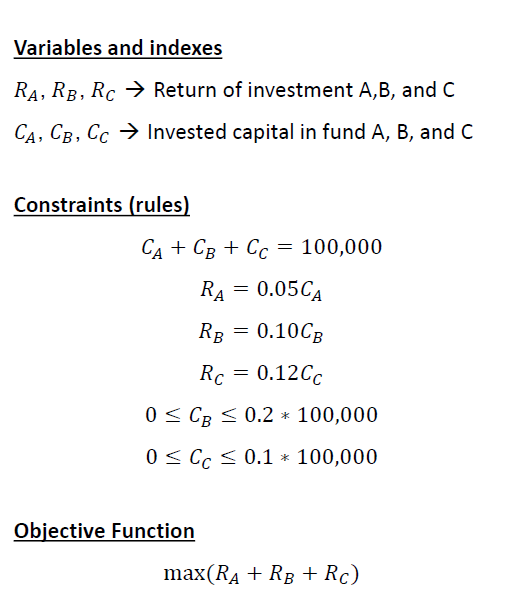

In [1]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

m = pyo.ConcreteModel()

#sets and parameters
m.setInv = pyo.Set(initialize=['A','B','C','D'])
m.Capital = 100000

#variables
m.C = pyo.Var(m.setInv, bounds=(0,None))
m.R = pyo.Var(m.setInv, bounds=(0,None))

#objective function
m.obj = pyo.Objective(expr = pyo.summation(m.R), sense=pyo.maximize)

#constraints
m.C1 = pyo.Constraint(expr = pyo.summation(m.C) == m.Capital)
m.C2 = pyo.Constraint(expr = m.R['A'] == 0.05*m.C['A'])
m.C3 = pyo.Constraint(expr = m.R['B'] == 0.10*m.C['B'])
m.C4 = pyo.Constraint(expr = m.R['C'] == 0.12*m.C['C'])
m.C5 = pyo.Constraint(expr = m.R['D'] == 1e-6*m.C['D']**2)

m.C6 = pyo.Constraint(expr = m.C['B'] <= 0.2*m.Capital)
m.C7 = pyo.Constraint(expr = m.C['C'] <= 0.1*m.Capital)
m.C8 = pyo.Constraint(expr = m.C['D'] <= 0.3*m.Capital)

#solve
opt = SolverFactory('gurobi')
m.results = opt.solve(m)

#print
m.pprint()
print('\n\nOF:',pyo.value(m.obj))

1 Set Declarations
    setInv : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    4 : {'A', 'B', 'C', 'D'}

2 Var Declarations
    C : Size=4, Index=setInv
        Key : Lower : Value   : Upper : Fixed : Stale : Domain
          A :     0 : 70000.0 :  None : False : False :  Reals
          B :     0 : 20000.0 :  None : False : False :  Reals
          C :     0 : 10000.0 :  None : False : False :  Reals
          D :     0 :     0.0 :  None : False : False :  Reals
    R : Size=4, Index=setInv
        Key : Lower : Value  : Upper : Fixed : Stale : Domain
          A :     0 : 3500.0 :  None : False : False :  Reals
          B :     0 : 2000.0 :  None : False : False :  Reals
          C :     0 : 1200.0 :  None : False : False :  Reals
          D :     0 :    0.0 :  None : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
      

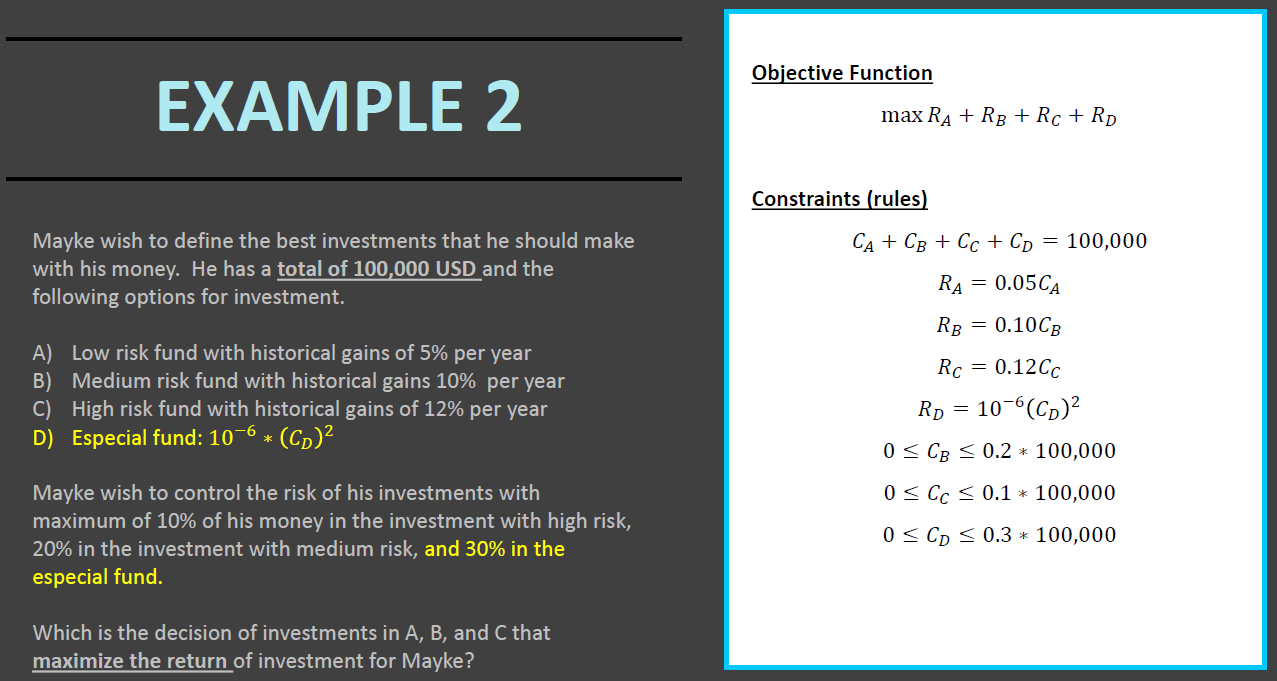

In [2]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

m = pyo.ConcreteModel()

#sets and parameters
m.setMachine = pyo.Set(initialize=['A','B','C'])
m.Demand = 10000

#variables
m.C = pyo.Var(m.setMachine, bounds=(0,None))
m.P = pyo.Var(m.setMachine, within=pyo.Integers, bounds=(0,None))

#objective function
m.obj = pyo.Objective(expr = pyo.summation(m.C), sense=pyo.minimize)

#constraints
m.C1 = pyo.Constraint(expr = pyo.summation(m.P) == m.Demand)
m.C2 = pyo.Constraint(expr = m.C['A'] == 0.1*m.P['A']**2 + 0.5*m.P['A'] + 0.1)
m.C3 = pyo.Constraint(expr = m.C['B'] == 0.3*m.P['B'] + 0.5)
m.C4 = pyo.Constraint(expr = m.C['C'] == 0.01*m.P['C']**3)

#solve
opt = SolverFactory('couenne', executable=r"solvers\couenne.exe")
m.results = opt.solve(m)

#print
m.pprint()

print('\n\nOF:',pyo.value(m.obj))

1 Set Declarations
    setMachine : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {'A', 'B', 'C'}

2 Var Declarations
    C : Size=3, Index=setMachine
        Key : Lower : Value               : Upper : Fixed : Stale : Domain
          A :     0 :                 0.1 :  None : False : False :  Reals
          B :     0 :              2999.6 :  None : False : False :  Reals
          C :     0 : 0.26999999999998203 :  None : False : False :  Reals
    P : Size=3, Index=setMachine
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          A :     0 :                0.0 :  None : False : False : Integers
          B :     0 :             9997.0 :  None : False : False : Integers
          C :     0 : 2.9999999999999334 :  None : False : False : Integers

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True 

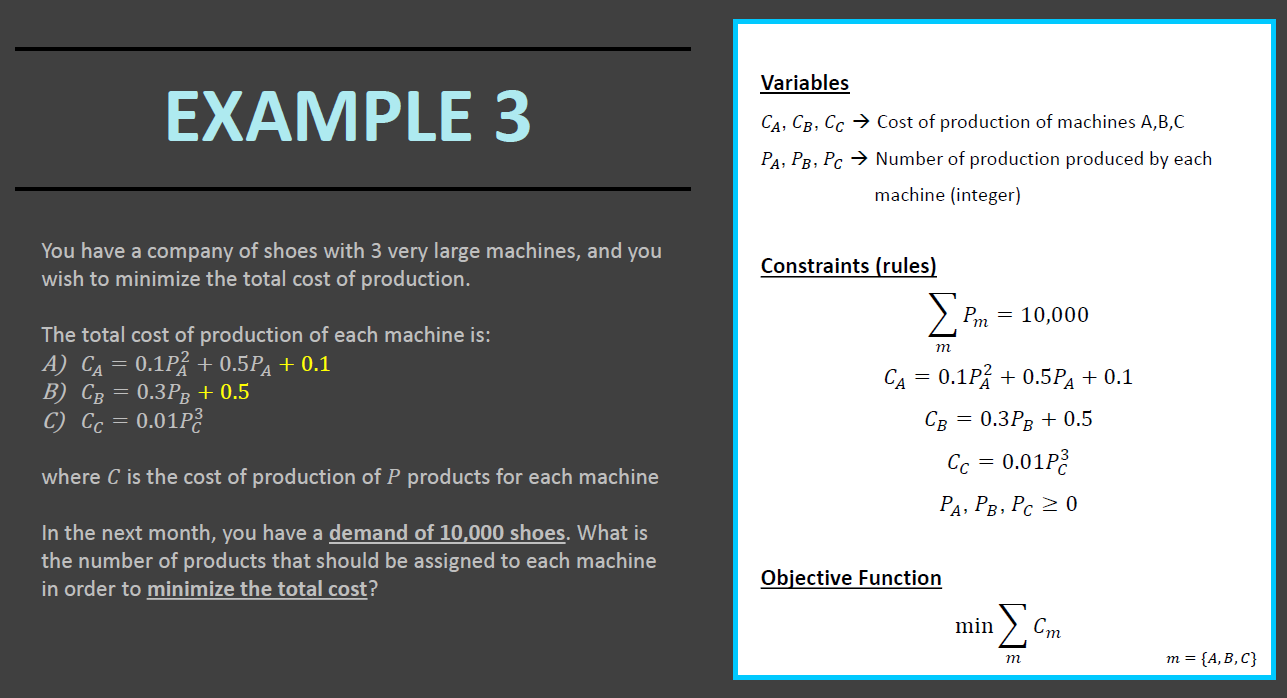

In [3]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

m = pyo.ConcreteModel()

#sets and parameters
m.setMachine = pyo.Set(initialize=['A','B','C'])
m.Demand = 10000
M = 1e6

#variables
m.C = pyo.Var(m.setMachine, bounds=(0,None))
m.P = pyo.Var(m.setMachine, within=pyo.Integers, bounds=(0,None))
m.B = pyo.Var(m.setMachine, within=pyo.Binary)

#objective function
m.obj = pyo.Objective(expr = pyo.summation(m.C), sense=pyo.minimize)

#constraints
m.C1 = pyo.Constraint(expr = pyo.summation(m.P) == m.Demand)
m.C2 = pyo.Constraint(expr = m.C['A'] == 0.1*m.P['A']**2 + 0.5*m.P['A'] + m.B['A']*0.1)
m.C3 = pyo.Constraint(expr = m.C['B'] == 0.3*m.P['B'] + m.B['B']*0.5)
m.C4 = pyo.Constraint(expr = m.C['C'] == 0.01*m.P['C']**3)

m.C5 = pyo.Constraint(expr = m.P['A'] <= m.B['A']*M)
m.C6 = pyo.Constraint(expr = m.P['B'] <= m.B['B']*M)

#solve
opt = SolverFactory('couenne', executable=r"solvers\couenne.exe")
m.results = opt.solve(m)

#print
m.pprint()

print('\n\nOF:',pyo.value(m.obj))

1 Set Declarations
    setMachine : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {'A', 'B', 'C'}

3 Var Declarations
    B : Size=3, Index=setMachine
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          A :     0 :   0.0 :     1 : False : False : Binary
          B :     0 :   1.0 :     1 : False : False : Binary
          C :     0 :  None :     1 : False :  True : Binary
    C : Size=3, Index=setMachine
        Key : Lower : Value              : Upper : Fixed : Stale : Domain
          A :     0 :                0.0 :  None : False : False :  Reals
          B :     0 : 2999.2999999999997 :  None : False : False :  Reals
          C :     0 :               0.64 :  None : False : False :  Reals
    P : Size=3, Index=setMachine
        Key : Lower : Value  : Upper : Fixed : Stale : Domain
          A :     0 :    0.0 :  None : False : False : Integers
          B :     0 : 9996.0 :  None : 

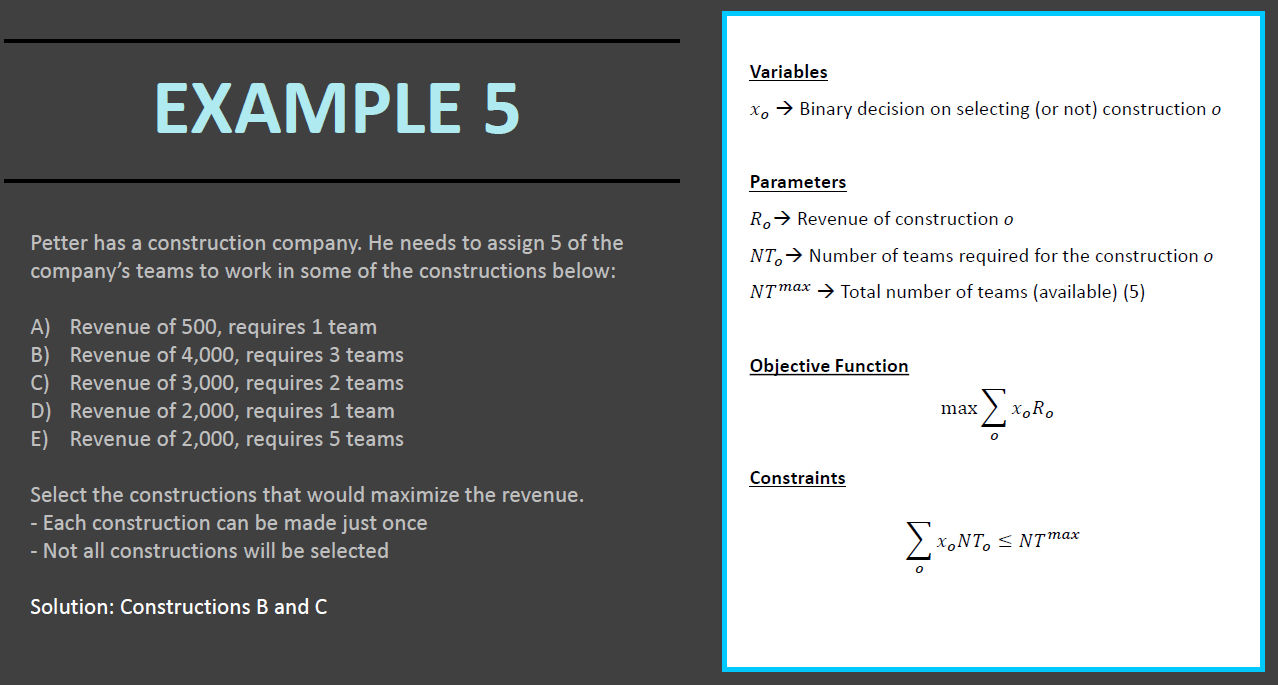

In [4]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

m = pyo.ConcreteModel()

#sets 
m.setO = pyo.Set(initialize=['A','B','C','D','E'])
m.R = {'A':500, 'B':4000, 'C':3000, 'D':2000, 'E':2000}
m.NT = {'A':1, 'B':3, 'C':2, 'D':1, 'E':5}
m.Nteams = 5

#variables
m.x = pyo.Var(m.setO, within=pyo.Binary)

#objective function
m.obj = pyo.Objective(expr = sum([m.x[o]*m.R[o] for o in m.setO]), sense=pyo.maximize)

#constraints
m.C1 = pyo.Constraint(expr = sum([m.x[o]*m.NT[o] for o in m.setO]) <= m.Nteams)


#solve
opt = SolverFactory('gurobi')
m.results = opt.solve(m)

#print
m.pprint()
print('\n\nOF:',pyo.value(m.obj))

1 Set Declarations
    setO : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    5 : {'A', 'B', 'C', 'D', 'E'}

1 Var Declarations
    x : Size=5, Index=setO
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          A :     0 :   0.0 :     1 : False : False : Binary
          B :     0 :   1.0 :     1 : False : False : Binary
          C :     0 :   1.0 :     1 : False : False : Binary
          D :     0 :   0.0 :     1 : False : False : Binary
          E :     0 :   0.0 :     1 : False : False : Binary

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 500*x[A] + 4000*x[B] + 3000*x[C] + 2000*x[D] + 2000*x[E]

1 Constraint Declarations
    C1 : Size=1, Index=None, Active=True
        Key  : Lower : Body                                   : Upper : Active
        None :  -Inf : x[A] + 3*x[B] + 2*x[C] + x[D] +

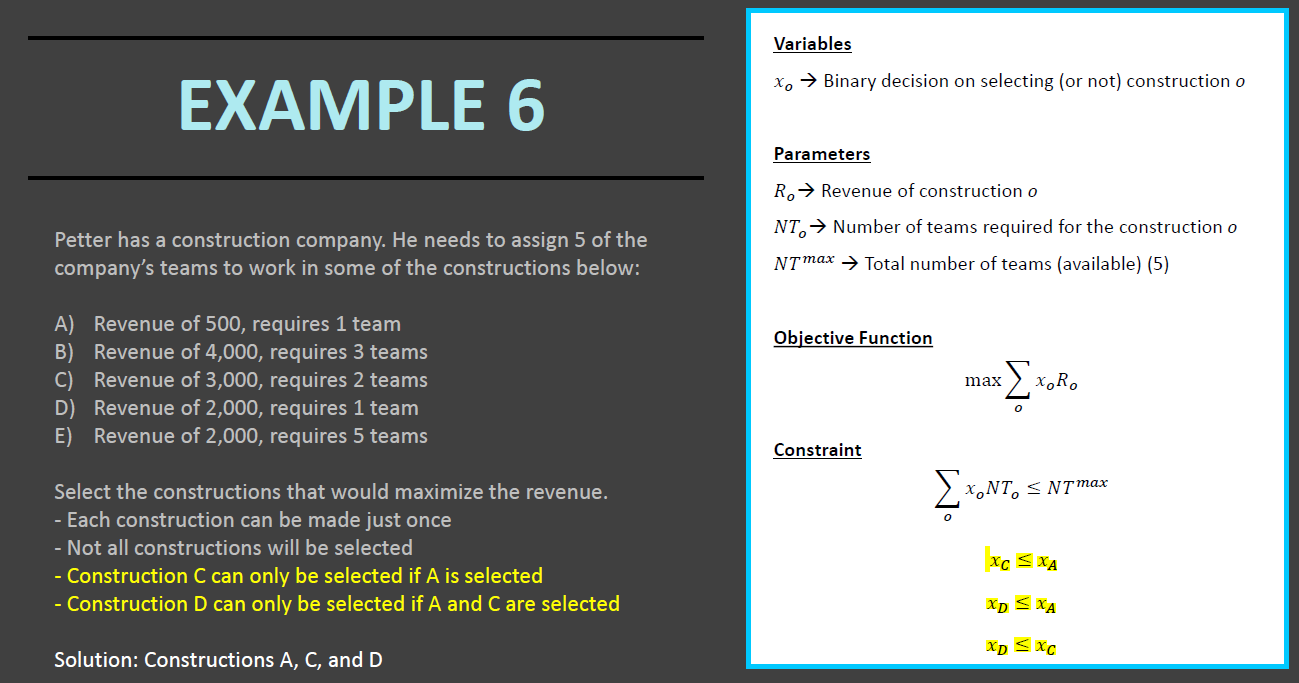

In [5]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

m = pyo.ConcreteModel()

#sets 
m.setO = pyo.Set(initialize=['A','B','C','D','E'])
m.R = {'A':500, 'B':4000, 'C':3000, 'D':2000, 'E':2000}
m.NT = {'A':1, 'B':3, 'C':2, 'D':1, 'E':5}
m.Nteams = 5

#variables
m.x = pyo.Var(m.setO, within=pyo.Binary)

#objective function
m.obj = pyo.Objective(expr = sum([m.x[o]*m.R[o] for o in m.setO]), sense=pyo.maximize)

#constraints
m.C1 = pyo.Constraint(expr = sum([m.x[o]*m.NT[o] for o in m.setO]) <= m.Nteams)
m.C2 = pyo.Constraint(expr = m.x['C'] <= m.x['A'])
m.C3 = pyo.Constraint(expr = m.x['D'] <= m.x['A'])
m.C4 = pyo.Constraint(expr = m.x['D'] <= m.x['C'])


#solve
opt = SolverFactory('gurobi')
m.results = opt.solve(m)

#print
m.pprint()
print('\n\nOF:',pyo.value(m.obj))

1 Set Declarations
    setO : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    5 : {'A', 'B', 'C', 'D', 'E'}

1 Var Declarations
    x : Size=5, Index=setO
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          A :     0 :   1.0 :     1 : False : False : Binary
          B :     0 :   0.0 :     1 : False : False : Binary
          C :     0 :   1.0 :     1 : False : False : Binary
          D :     0 :   1.0 :     1 : False : False : Binary
          E :     0 :   0.0 :     1 : False : False : Binary

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 500*x[A] + 4000*x[B] + 3000*x[C] + 2000*x[D] + 2000*x[E]

4 Constraint Declarations
    C1 : Size=1, Index=None, Active=True
        Key  : Lower : Body                                   : Upper : Active
        None :  -Inf : x[A] + 3*x[B] + 2*x[C] + x[D] +

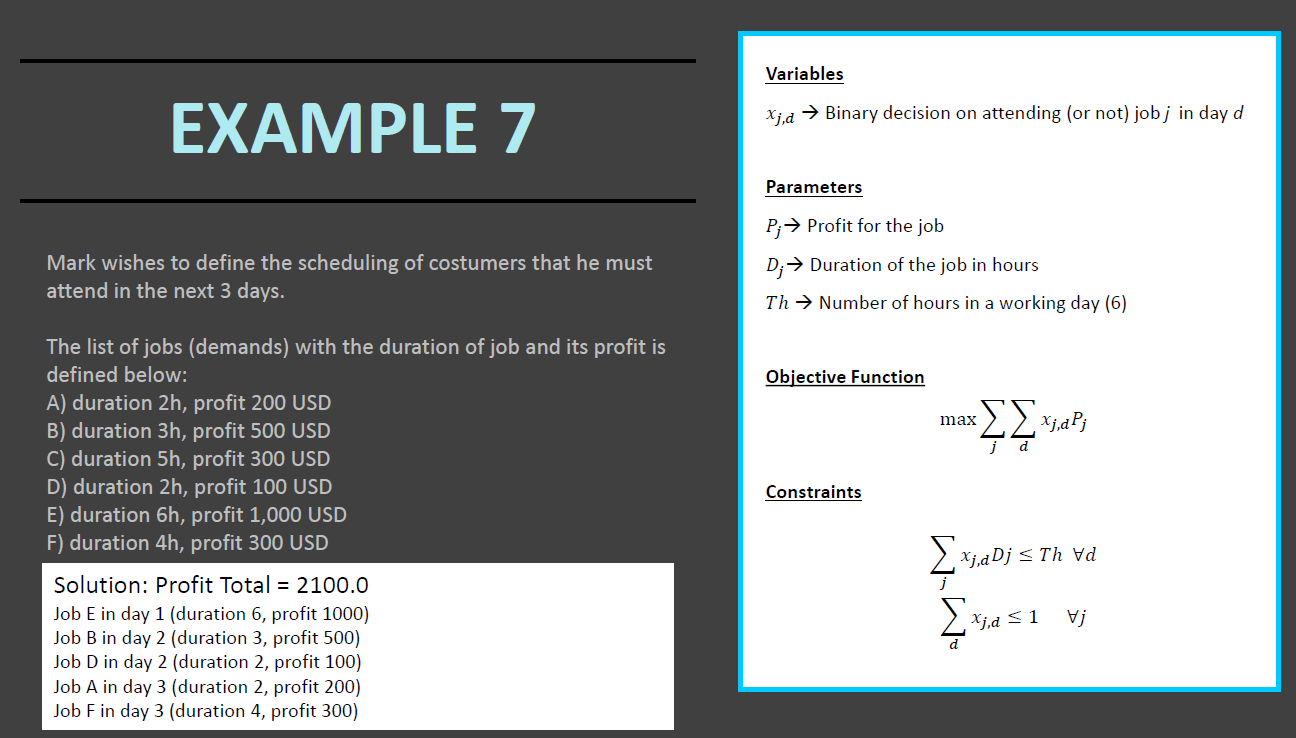

In [6]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

m = pyo.ConcreteModel()

#sets 
m.setJ = pyo.Set(initialize=['A','B','C','D','E','F'])
m.setD = pyo.Set(initialize=[1,2,3])
m.D = {'A':2, 'B':3, 'C':5, 'D':2, 'E':6, 'F':4}
m.P = {'A':200, 'B':500, 'C':300, 'D':100, 'E':1000, 'F':300}
m.maxHours = 6

#variables
m.x = pyo.Var(m.setJ, m.setD, within=pyo.Binary)

#objective function
m.obj = pyo.Objective(expr = sum([m.x[j,d]*m.P[j] for j in m.setJ for d in m.setD]), sense=pyo.maximize)

#constraints
m.C1 = pyo.ConstraintList()
m.C2 = pyo.ConstraintList()

for d in m.setD:
    m.C1.add(sum([m.x[j,d]*m.D[j] for j in m.setJ]) <= m.maxHours)
for j in m.setJ:
    m.C2.add(sum([m.x[j,d] for d in m.setD]) <= 1)


#solve
opt = SolverFactory('gurobi')
m.results = opt.solve(m)

#print
m.pprint()

print('\n\n')
print('Profit Total:', pyo.value(m.obj))
for d in m.setD:
    for j in m.setJ:
        if pyo.value(m.x[j,d])>0.9:
            print('Job %s in day %d (duration %i, profit %i)' % (j,d,m.D[j],m.P[j]))

2 Set Declarations
    setD : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {1, 2, 3}
    setJ : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    6 : {'A', 'B', 'C', 'D', 'E', 'F'}

1 Var Declarations
    x : Size=18, Index=setJ*setD
        Key      : Lower : Value : Upper : Fixed : Stale : Domain
        ('A', 1) :     0 :   1.0 :     1 : False : False : Binary
        ('A', 2) :     0 :  -0.0 :     1 : False : False : Binary
        ('A', 3) :     0 :  -0.0 :     1 : False : False : Binary
        ('B', 1) :     0 :  -0.0 :     1 : False : False : Binary
        ('B', 2) :     0 :   1.0 :     1 : False : False : Binary
        ('B', 3) :     0 :  -0.0 :     1 : False : False : Binary
        ('C', 1) :     0 :  -0.0 :     1 : False : False : Binary
        ('C', 2) :     0 :  -0.0 :     1 : False : False : Binary
        ('C', 3) :     

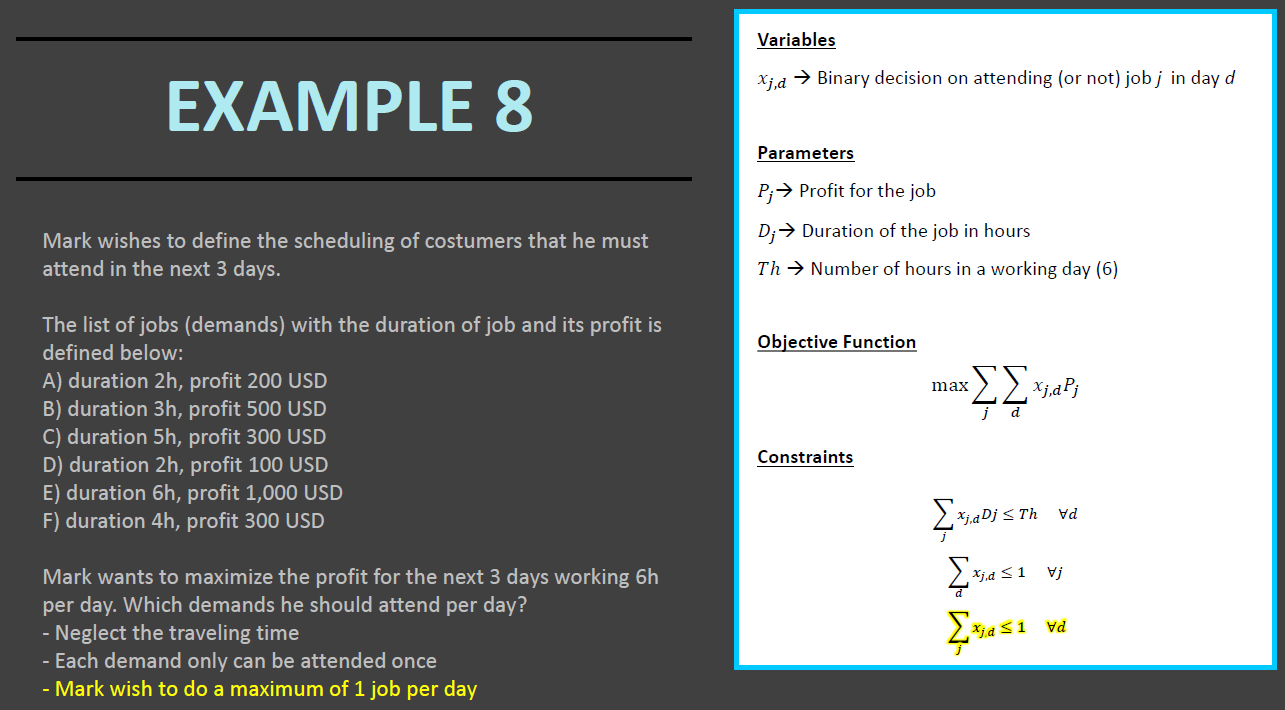

In [7]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

m = pyo.ConcreteModel()

#sets 
m.setJ = pyo.Set(initialize=['A','B','C','D','E','F'])
m.setD = pyo.Set(initialize=[1,2,3])
m.D = {'A':2, 'B':3, 'C':5, 'D':2, 'E':6, 'F':4}
m.P = {'A':200, 'B':500, 'C':300, 'D':100, 'E':1000, 'F':300}
m.maxHours = 6

#variables
m.x = pyo.Var(m.setJ, m.setD, within=pyo.Binary)

#objective function
m.obj = pyo.Objective(expr = sum([m.x[j,d]*m.P[j] for j in m.setJ for d in m.setD]), sense=pyo.maximize)

#constraints
m.C1 = pyo.ConstraintList()
m.C2 = pyo.ConstraintList()
m.C3 = pyo.ConstraintList()

for d in m.setD:
    m.C1.add(sum([m.x[j,d]*m.D[j] for j in m.setJ]) <= m.maxHours)
    m.C3.add(sum([m.x[j,d] for j in m.setJ]) <= 1)
for j in m.setJ:
    m.C2.add(sum([m.x[j,d] for d in m.setD]) <= 1)


#solve
opt = SolverFactory('gurobi')
m.results = opt.solve(m)

#print
m.pprint()

print('\n\n')
print('Total Profit:', pyo.value(m.obj))
for d in m.setD:
    for j in m.setJ:
        if pyo.value(m.x[j,d])>0.9:
            print('Job %s in day %d (duration %i, profit %i)' % (j,d,m.D[j],m.P[j]))

2 Set Declarations
    setD : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {1, 2, 3}
    setJ : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    6 : {'A', 'B', 'C', 'D', 'E', 'F'}

1 Var Declarations
    x : Size=18, Index=setJ*setD
        Key      : Lower : Value : Upper : Fixed : Stale : Domain
        ('A', 1) :     0 :  -0.0 :     1 : False : False : Binary
        ('A', 2) :     0 :  -0.0 :     1 : False : False : Binary
        ('A', 3) :     0 :  -0.0 :     1 : False : False : Binary
        ('B', 1) :     0 :   1.0 :     1 : False : False : Binary
        ('B', 2) :     0 :  -0.0 :     1 : False : False : Binary
        ('B', 3) :     0 :  -0.0 :     1 : False : False : Binary
        ('C', 1) :     0 :   0.0 :     1 : False : False : Binary
        ('C', 2) :     0 :  -0.0 :     1 : False : False : Binary
        ('C', 3) :     